# Week 1 Session 1: Introduction to Machine Learning

## Learning Objectives

By the end of this session, you will be able to:
1. Distinguish between supervised, unsupervised, and reinforcement learning
2. Understand core ML concepts: features, labels, training/testing data
3. Perform exploratory data analysis (EDA) on real datasets
4. Apply essential preprocessing techniques: encoding and scaling

## Session Outline

| Section | Topic |
|---------|-------|
| 1 | What is Machine Learning? |
| 2 | Supervised Learning: Regression Example |
| 3 | Unsupervised Learning: Clustering Example |
| 4 | Core ML Concepts |
| 5 | Exploratory Data Analysis |
| 6 | Data Preprocessing |
| 7 | Hands-On Exercise |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300
sns.set_style('whitegrid')
np.random.seed(42)

---
## 1. What is Machine Learning?

Machine learning is a subset of artificial intelligence where algorithms learn patterns from data to make predictions or decisions, without being explicitly programmed for each case.

### The Three Types of Machine Learning

| Type | Input | Goal | Example |
|------|-------|------|---------|
| **Supervised** | Labeled data (input-output pairs) | Learn a mapping from inputs to outputs | Predicting CO2 emissions from engine size |
| **Unsupervised** | Unlabeled data (inputs only) | Discover hidden structure or patterns | Customer segmentation |
| **Reinforcement** | Environment + rewards | Learn actions that maximize cumulative reward | Game-playing agents |


### The ML Pipeline

Every ML project follows a general workflow:

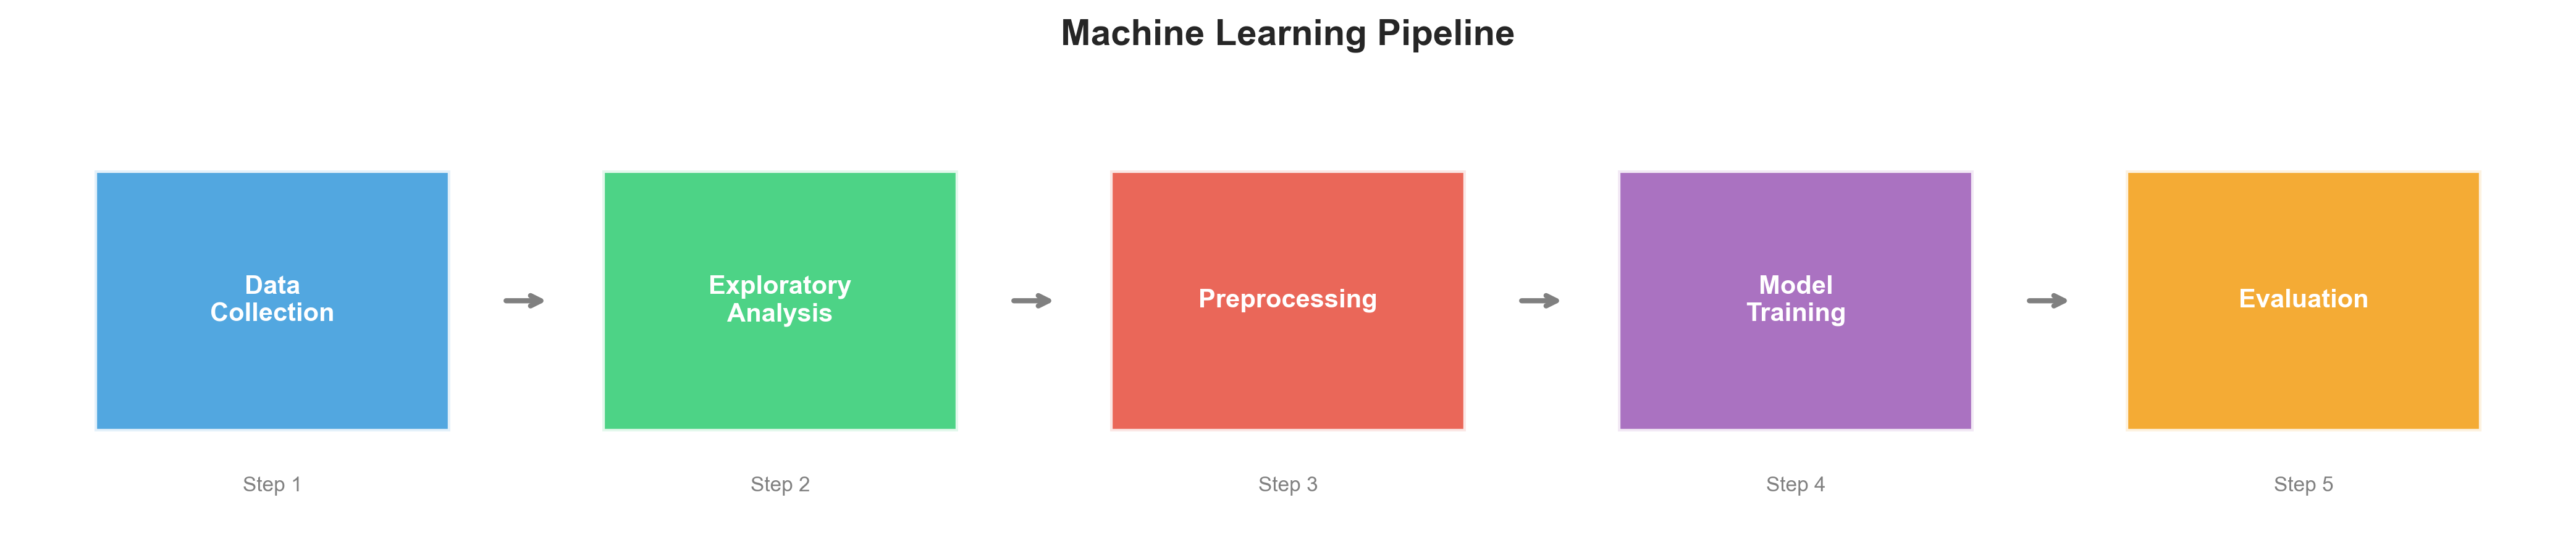

In [2]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

steps = ['Data\nCollection', 'Exploratory\nAnalysis', 'Preprocessing', 'Model\nTraining', 'Evaluation']
step_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for i, (step, color) in enumerate(zip(steps, step_colors)):
    x = i * 2 + 1
    ax.add_patch(plt.Rectangle((x - 0.7, 0.4), 1.4, 1.2, facecolor=color, edgecolor='white',
                                linewidth=2, alpha=0.85, zorder=2))
    ax.text(x, 1.0, step, ha='center', va='center', fontsize=10, fontweight='bold',
            color='white', zorder=3)
    ax.text(x, 0.15, f'Step {i+1}', ha='center', va='center', fontsize=8, color='gray')
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 0.9, 1.0), xytext=(x + 1.1, 1.0),
                    arrowprops=dict(arrowstyle='<-', color='gray', lw=2))

ax.set_title('Machine Learning Pipeline', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 2. Supervised Learning: Regression Example

In supervised learning, we train a model on **labeled data** -- each input has a known output. The model learns to predict the output for new, unseen inputs.

**Task:** Predict CO2 emissions from engine size using the `FuelConsumptionCo2` dataset.

In [3]:
# Load the dataset
fuel_df = pd.read_csv('../../Datasets/FuelConsumptionCo2.csv')

print(f'Dataset shape: {fuel_df.shape}')
print(f'Columns: {list(fuel_df.columns)}')
fuel_df.head()

Dataset shape: (1067, 13)
Columns: ['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS', 'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### Training a Simple Linear Regression Model

We use `ENGINESIZE` as the input feature (X) and `CO2EMISSIONS` as the target (y).

In [4]:
X = fuel_df[['ENGINESIZE']]
y = fuel_df['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Coefficient (slope): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')
print(f'Equation: CO2 = {model.coef_[0]:.2f} x EngineSize + {model.intercept_:.2f}')

Coefficient (slope): 38.99
Intercept: 126.29
Equation: CO2 = 38.99 x EngineSize + 126.29


### Visualizing the Regression Fit

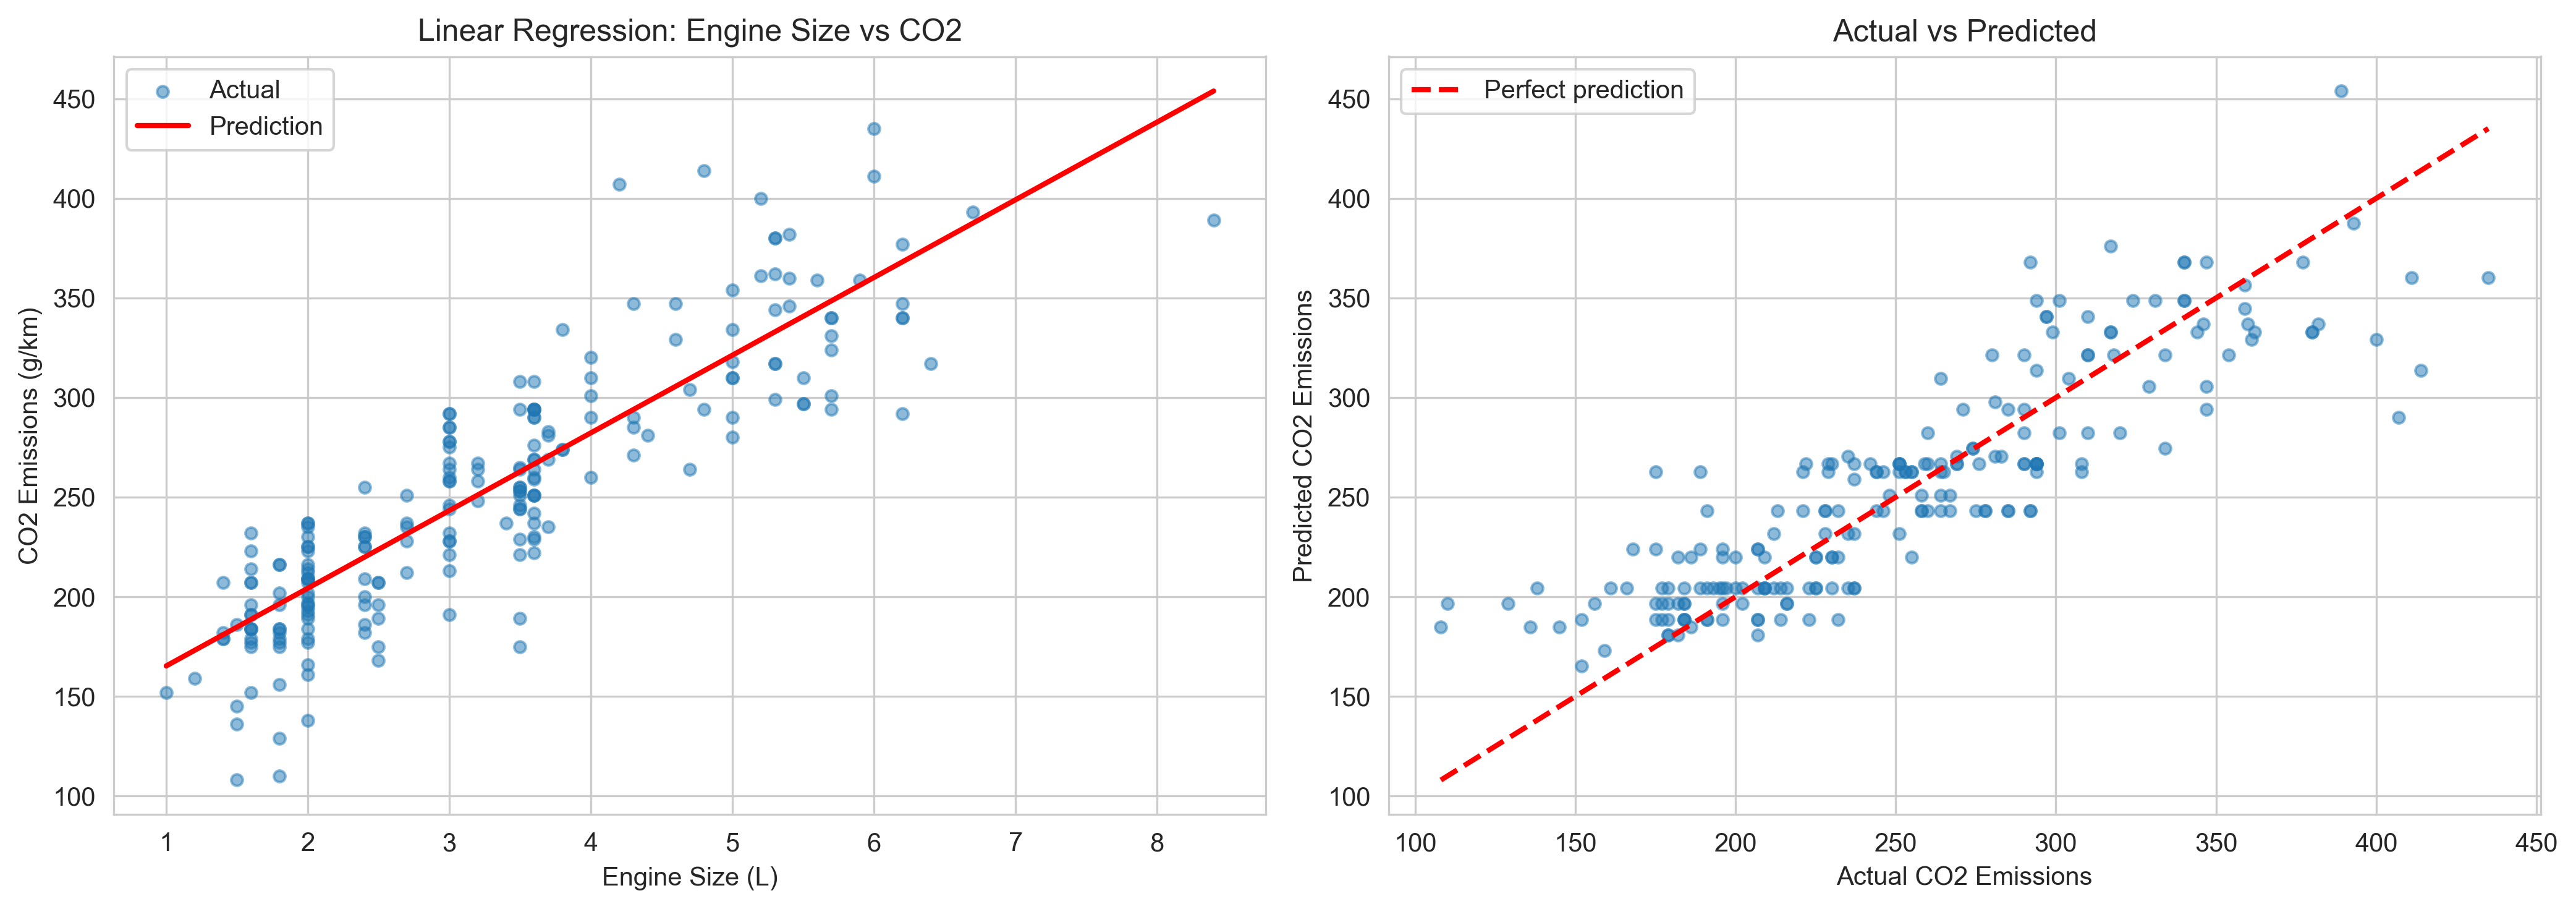

Mean Squared Error: 985.94
R-squared: 0.7616 (76.2% of variance explained)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression line
axes[0].scatter(X_test, y_test, alpha=0.5, s=20, label='Actual')
X_sorted = X_test.sort_values('ENGINESIZE')
axes[0].plot(X_sorted, model.predict(X_sorted), color='red', linewidth=2, label='Prediction')
axes[0].set_xlabel('Engine Size (L)')
axes[0].set_ylabel('CO2 Emissions (g/km)')
axes[0].set_title('Linear Regression: Engine Size vs CO2')
axes[0].legend()

# Actual vs predicted
axes[1].scatter(y_test, y_pred, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual CO2 Emissions')
axes[1].set_ylabel('Predicted CO2 Emissions')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.4f} ({r2*100:.1f}% of variance explained)')

---
## 3. Unsupervised Learning: Clustering Example

In unsupervised learning, there are **no labels**. The algorithm discovers patterns or groups in the data on its own.

**Task:** Segment AI job postings by salary and years of experience using K-Means clustering.

In [6]:
jobs_df = pd.read_csv('../../Datasets/ai_job_dataset.csv')

print(f'Dataset shape: {jobs_df.shape}')
jobs_df[['job_title', 'salary_usd', 'years_experience', 'experience_level']].head()

Dataset shape: (15000, 19)


,job_title,salary_usd,years_experience,experience_level
0,AI Research Scientist,90376,9,SE
1,AI Software Engineer,61895,1,EN
2,AI Specialist,152626,2,MI
3,NLP Engineer,80215,7,SE
4,AI Consultant,54624,0,EN


### Applying K-Means Clustering

We select two numeric features and let K-Means discover natural groupings.

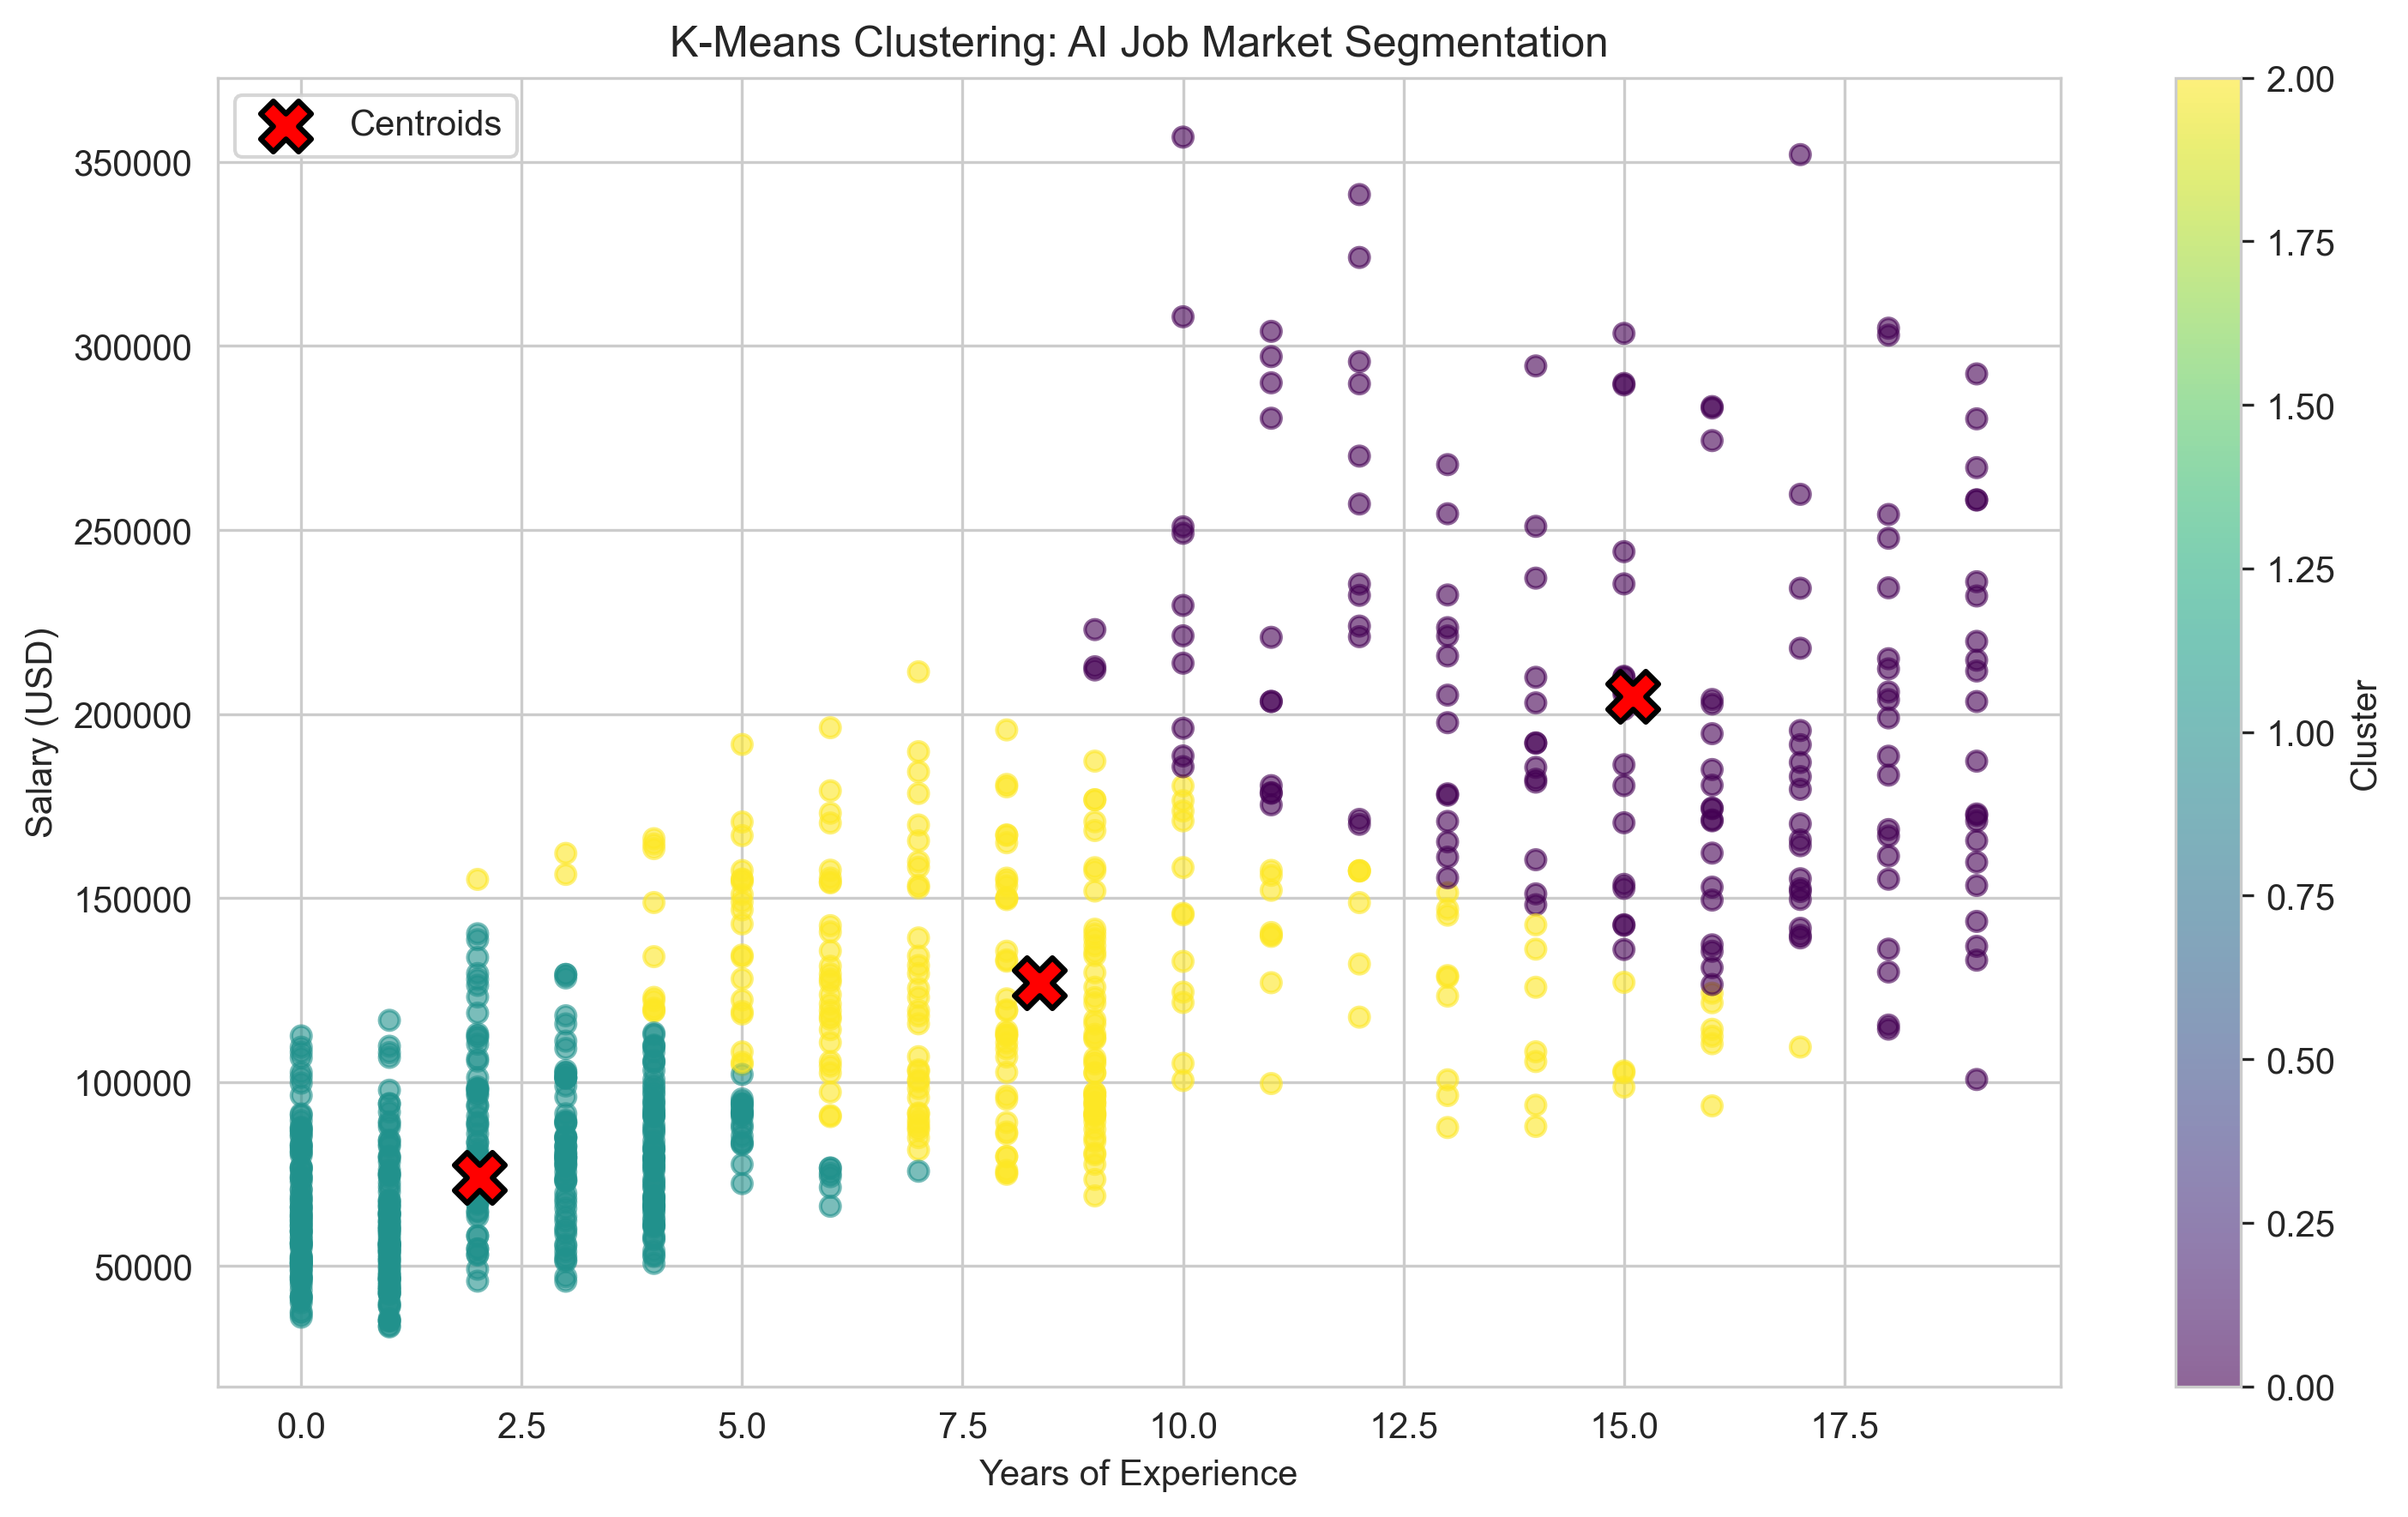

         avg_salary  avg_experience  count
Cluster                                   
0          204736.0            15.0    161
1           74157.0             2.0    407
2          126971.0             8.0    232


In [7]:
cluster_features = jobs_df[['salary_usd', 'years_experience']].dropna()
cluster_sample = cluster_features.sample(n=800, random_state=42)

# Scale features (important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_sample)

# Fit K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Visualize
plt.figure(figsize=(10, 6))
scatter = plt.scatter(cluster_sample['years_experience'], cluster_sample['salary_usd'],
                      c=clusters, cmap='viridis', alpha=0.6, s=30)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 1], centers[:, 0], c='red', marker='X', s=200,
            edgecolors='black', linewidths=1.5, label='Centroids')

plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.title('K-Means Clustering: AI Job Market Segmentation')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.tight_layout()
plt.show()

# Cluster summary
cluster_sample_labeled = cluster_sample.copy()
cluster_sample_labeled['Cluster'] = clusters
print(cluster_sample_labeled.groupby('Cluster').agg(
    avg_salary=('salary_usd', 'mean'),
    avg_experience=('years_experience', 'mean'),
    count=('salary_usd', 'count')
).round(0))

**Key takeaway:** The algorithm grouped jobs into segments without being told what the groups should be. This is the essence of unsupervised learning.

---
## 4. Core ML Concepts

### Features and Labels

| Term | Definition | Example (FuelConsumption dataset) |
|------|-----------|-----------------------------------|
| **Feature** (X) | Input variable used for prediction | Engine size, cylinders, fuel consumption |
| **Label/Target** (y) | Output variable to predict | CO2 emissions |
| **Training set** | Data used to train the model | 80% of the dataset |
| **Test set** | Data held out to evaluate the model | 20% of the dataset |

In [8]:
# Demonstrating train/test split with multiple features
X = fuel_df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = fuel_df['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Total samples: {len(X)}')
print(f'Training set:  {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set:      {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nFeatures (X): {list(X.columns)}')
print(f'Target (y):   CO2EMISSIONS')

Total samples: 1067
Training set:  853 samples (80%)
Test set:      214 samples (20%)

Features (X): ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']
Target (y):   CO2EMISSIONS


### ML Pipeline Walkthrough

Putting it all together -- the complete workflow using multiple features from the FuelConsumption data.

In [9]:
# Step 1: Data is already loaded (fuel_df)

# Step 2: Exploration
print('Step 2 - Exploration:')
print(f'  Shape: {fuel_df.shape}')
print(f'  Missing values: {fuel_df.isnull().sum().sum()}')

# Step 3: Preprocessing (select features, split)
X = fuel_df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = fuel_df['CO2EMISSIONS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Evaluation
y_pred = model.predict(X_test)
print(f'\nStep 5 - Evaluation:')
print(f'  R-squared: {r2_score(y_test, y_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

print(f'\nFeature coefficients:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature}: {coef:.4f}')

Step 2 - Exploration:
  Shape: (1067, 13)
  Missing values: 0

Step 5 - Evaluation:
  R-squared: 0.8760
  RMSE: 22.65

Feature coefficients:
  ENGINESIZE: 11.2094
  CYLINDERS: 7.1556
  FUELCONSUMPTION_COMB: 9.5208


### Key Vocabulary

| Term | Definition |
|------|------------|
| **Model** | An algorithm trained on data to make predictions |
| **Training** | The process of learning parameters from data |
| **Prediction** | Applying the trained model to new inputs |
| **Overfitting** | Model memorizes training data but fails on new data |
| **Underfitting** | Model is too simple to capture the underlying pattern |
| **Evaluation metric** | A measure of model performance (e.g., R-squared, MSE) |

---
## 5. Exploratory Data Analysis (EDA)

Before building any model, we must understand the data. EDA answers:
- How many samples and features do we have?
- Are there missing values?
- What are the distributions of each feature?
- Which features are correlated?

**Dataset:** `1000_Companies.csv` -- predicting company profit from R&D, Administration, and Marketing spend.

In [10]:
companies_df = pd.read_csv('../../Datasets/1000_Companies.csv')

print(f'Shape: {companies_df.shape}')
print(f'\nColumn types:')
print(companies_df.dtypes)
print(f'\nMissing values:')
print(companies_df.isnull().sum())
print(f'\nStatistical summary:')
companies_df.describe().round(2)

Shape: (1000, 5)

Column types:
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

Missing values:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Statistical summary:


,R&D Spend,Administration,Marketing Spend,Profit
count,1000.00,1000.00,1000.00,1000.00
mean,81668.93,122963.90,226205.06,119546.16
std,46537.57,12613.93,91578.39,42888.63
min,0.00,51283.14,0.00,14681.40
25%,43084.50,116640.68,150969.58,85943.20
50%,79936.00,122421.61,224517.89,117641.47
75%,124565.50,129139.12,308189.81,155577.11
max,165349.20,321652.14,471784.10,476485.43


### Distributions and Correlations

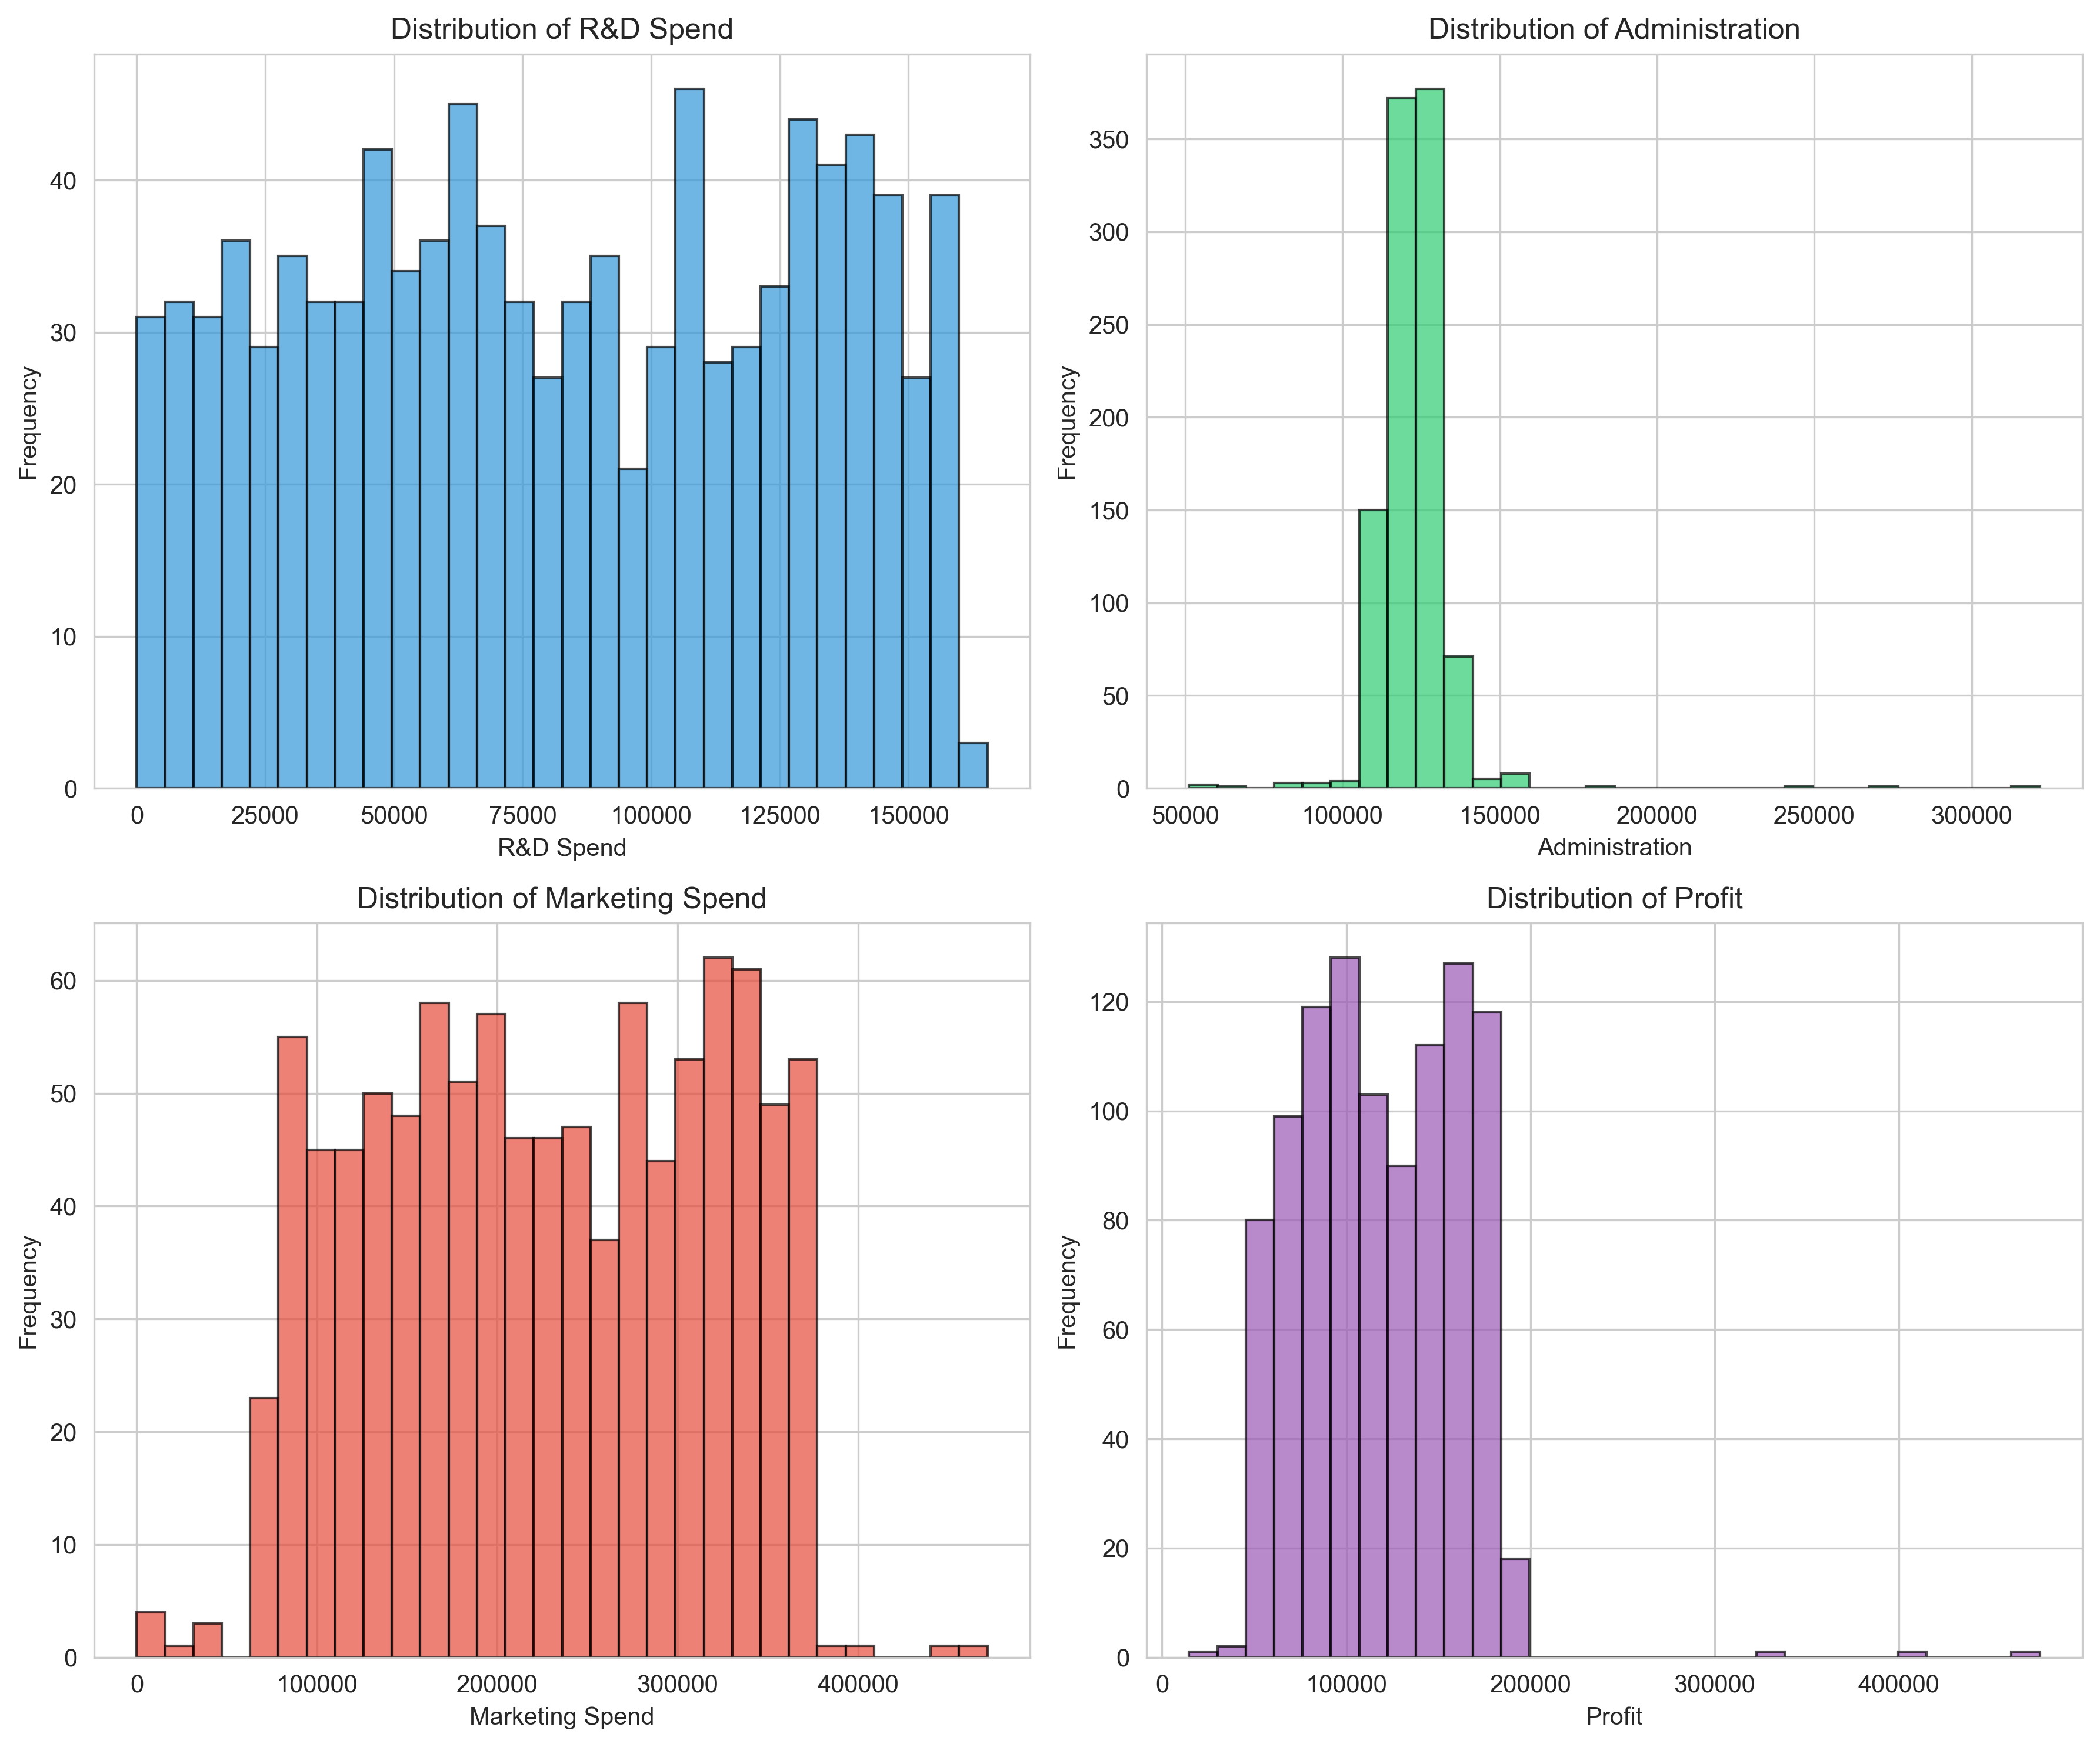

In [11]:
numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
for i, col in enumerate(numeric_cols):
    ax = axes[i // 2, i % 2]
    ax.hist(companies_df[col], bins=30, edgecolor='black', alpha=0.7, color=plot_colors[i])
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

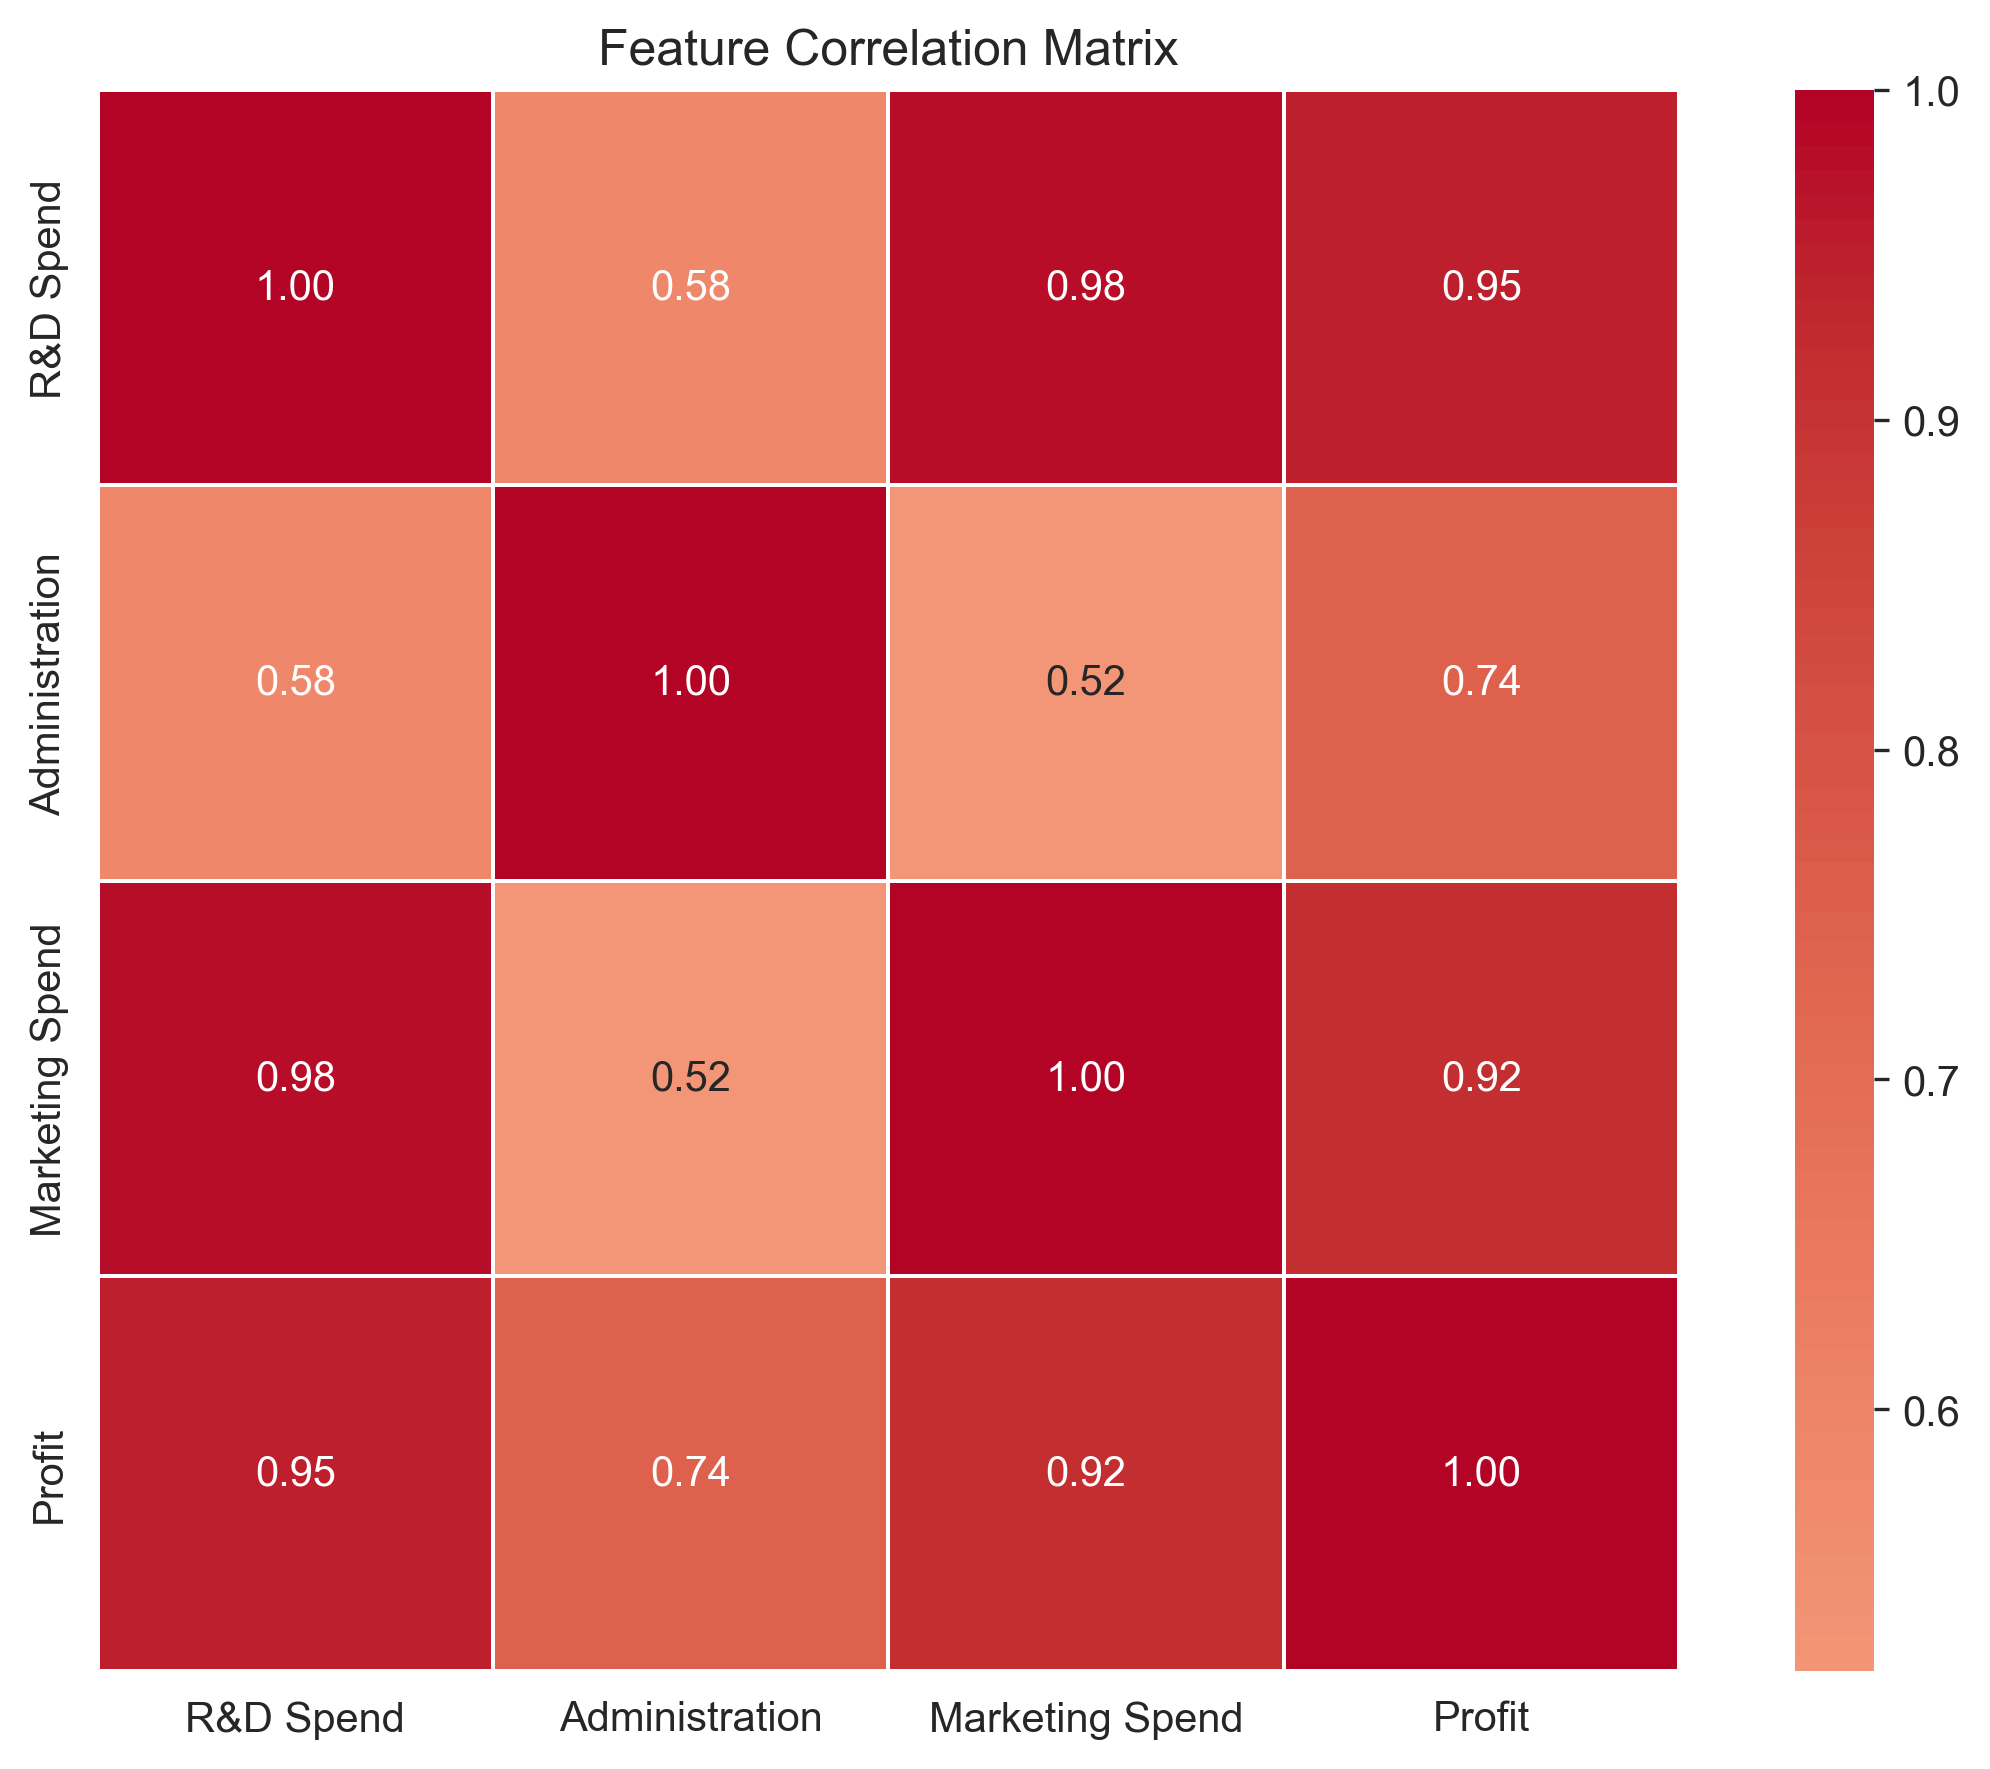

Key observations:
  R&D Spend vs Profit correlation: 0.945
  Marketing Spend vs Profit correlation: 0.917
  Administration vs Profit correlation: 0.742


In [12]:
plt.figure(figsize=(8, 6))
corr_matrix = companies_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('Key observations:')
print(f'  R&D Spend vs Profit correlation: {corr_matrix.loc["R&D Spend", "Profit"]:.3f}')
print(f'  Marketing Spend vs Profit correlation: {corr_matrix.loc["Marketing Spend", "Profit"]:.3f}')
print(f'  Administration vs Profit correlation: {corr_matrix.loc["Administration", "Profit"]:.3f}')

---
## 6. Data Preprocessing

Raw data often needs transformation before modeling. The two most common preprocessing steps:
1. **Encoding categorical variables** -- converting text categories to numbers
2. **Feature scaling** -- normalizing numeric features to similar ranges

### 6.1 Encoding Categorical Variables

The `State` column in our companies dataset is categorical. Most ML algorithms require numeric input.

In [13]:
print('Unique states:', companies_df['State'].unique())
print(f'Number of unique values: {companies_df["State"].nunique()}')

# One-hot encoding creates a binary column for each category
companies_encoded = pd.get_dummies(companies_df, columns=['State'], drop_first=True, dtype=int)

print(f'\nBefore encoding: {companies_df.shape[1]} columns')
print(f'After encoding:  {companies_encoded.shape[1]} columns')
print(f'New columns: {[col for col in companies_encoded.columns if "State" in col]}')
companies_encoded.head()

Unique states: ['New York' 'California' 'Florida']
Number of unique values: 3

Before encoding: 5 columns
After encoding:  6 columns
New columns: ['State_Florida', 'State_New York']


,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


### 6.2 Feature Scaling

Features with very different scales can bias distance-based algorithms. **StandardScaler** transforms each feature to have mean=0 and standard deviation=1.

> **When to scale:** Always for distance-based models (KNN, SVM, K-Means). Optional for tree-based models (Random Forest, Decision Trees).

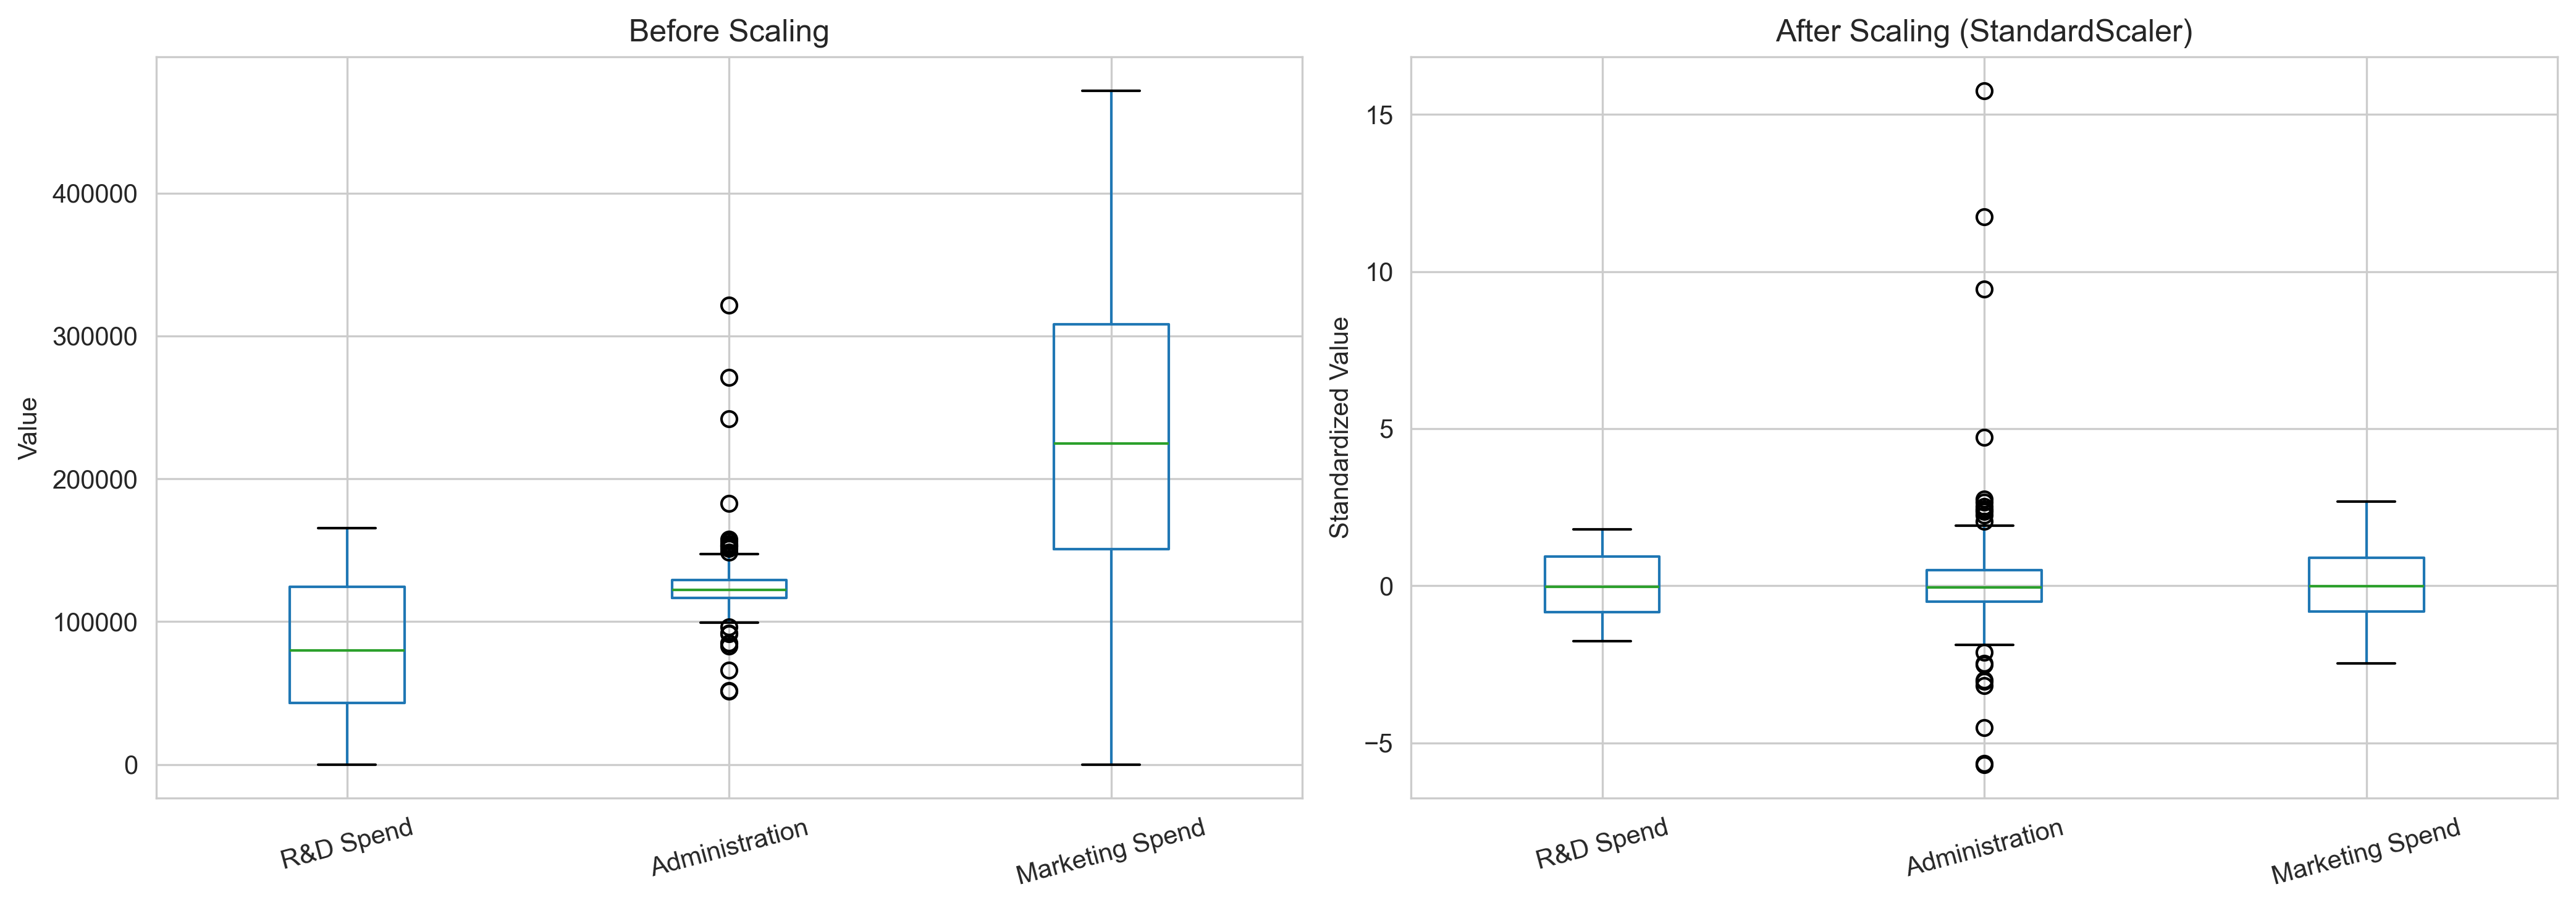

After scaling -- all features have approximately mean=0 and std=1:
      R&D Spend  Administration  Marketing Spend
mean    -0.0000          0.0000           0.0000
std      1.0005          1.0005           1.0005


In [14]:
features_to_scale = ['R&D Spend', 'Administration', 'Marketing Spend']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(companies_df[features_to_scale])
companies_scaled = pd.DataFrame(scaled_values, columns=features_to_scale)

# Compare before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

companies_df[features_to_scale].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=15)

companies_scaled.boxplot(ax=axes[1])
axes[1].set_title('After Scaling (StandardScaler)')
axes[1].set_ylabel('Standardized Value')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print('After scaling -- all features have approximately mean=0 and std=1:')
print(companies_scaled.describe().loc[['mean', 'std']].round(4))

### 6.3 Complete Preprocessing Pipeline

In [15]:
# 1. Encode categorical variables
companies_processed = pd.get_dummies(companies_df, columns=['State'], drop_first=True, dtype=int)

# 2. Separate features and target
X = companies_processed.drop('Profit', axis=1)
y = companies_processed['Profit']

# 3. Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'Final feature matrix shape: {X_scaled.shape}')
print(f'Target shape: {y.shape}')
print(f'Features: {list(X_scaled.columns)}')
X_scaled.head()

Final feature matrix shape: (1000, 5)
Target shape: (1000,)
Features: ['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']


,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,1.799023,1.105197,2.682968,-0.689149,1.412095
1,1.739869,2.253692,2.378316,-0.689149,-0.708168
2,1.543022,-1.730568,1.985407,1.451065,-0.708168
3,1.348048,-0.340433,1.715177,-0.689149,1.412095
4,1.299351,-2.504210,1.529110,1.451065,-0.708168


---
## 7. Hands-On Exercise

Apply what you have learned to a new dataset.

**Dataset:** `ENB2012_data.xlsx` -- Building energy efficiency data with 8 input features (X1-X8) and 2 outputs (Y1=heating load, Y2=cooling load).

**Tasks:**
1. Load the dataset and perform EDA (shape, types, missing values, distributions)
2. Create a correlation heatmap
3. Select features (X1-X8) and one target (Y1 = heating load)
4. Split into train/test sets (80/20)
5. Train a linear regression model and report R-squared and RMSE

In [16]:
# TODO: Load the dataset (hint: use pd.read_excel for .xlsx files)
# energy_df = pd.read_excel('../../Datasets/ENB2012_data.xlsx')

# TODO: Explore the data
# print(energy_df.shape)
# print(energy_df.describe())

# TODO: Create a correlation heatmap

# TODO: Prepare features and target
# X = energy_df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
# y = energy_df['Y1']

# TODO: Split, train, and evaluate


---
## Session Summary

- **Supervised learning** uses labeled data to learn input-output mappings (e.g., regression, classification)
- **Unsupervised learning** finds hidden patterns in unlabeled data (e.g., clustering)
- **EDA** is essential before modeling: check shape, types, missing values, distributions, correlations
- **Preprocessing** prepares data for algorithms: encode categories, scale features
- The **ML pipeline** provides a systematic workflow from data to evaluation